## Notebook 04 — Data Visualisation

**Objectives:** Create 4 plot types to explore flood risk patterns and answer Business Requirement 1

**Inputs:** outputs/v1/featured_data.csv

**Outputs:** outputs/v1/plots/ — 4 static PNG plots

In [1]:
# Notebook 04 — Data Visualisation
# Objectives: Create 4 plot types to explore flood risk patterns
# Inputs: outputs/v1/featured_data.csv
# Outputs: 4 plots saved to outputs/v1/plots/`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load featured data
df = pd.read_csv('../outputs/v1/featured_data.csv')

# Create plots output folder
os.makedirs('../outputs/v1/plots', exist_ok=True)

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Matplotlib is building the font cache; this may take a moment.


Shape: (458, 12)
Columns: ['name', 'ref', 'longitude', 'latitude', 'region', 'elevation_m', 'distance_to_river_m', 'flood_risk', 'flood_depth_m', 'elevation_category', 'distance_category', 'flood_risk_encoded']


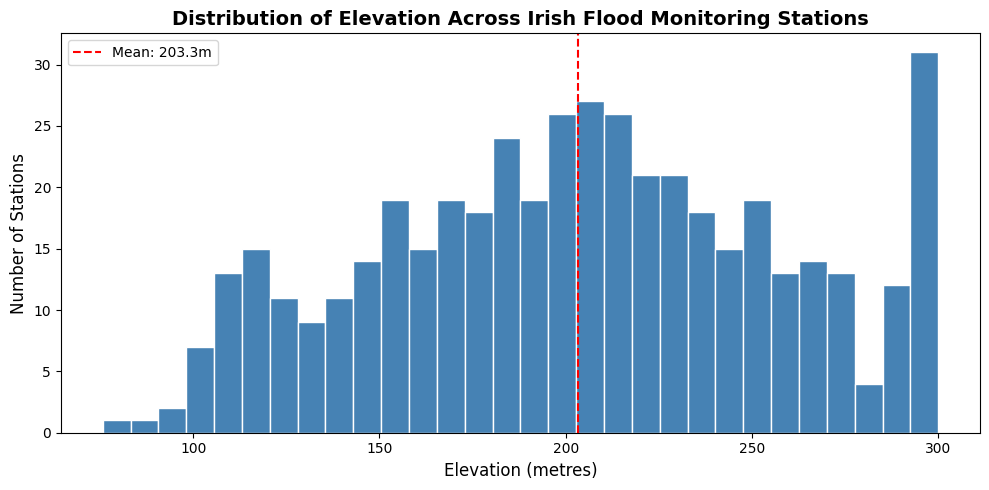

Plot 1 saved


In [3]:
# Plot 1 — Histogram: Elevation distribution
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['elevation_m'], bins=30, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Elevation Across Irish Flood Monitoring Stations', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Elevation (metres)', fontsize=12)
ax.set_ylabel('Number of Stations', fontsize=12)
ax.axvline(df['elevation_m'].mean(), color='red', linestyle='--', 
           label=f"Mean: {df['elevation_m'].mean():.1f}m")
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/v1/plots/01_elevation_histogram.png', dpi=150)
plt.show()
print("Plot 1 saved")

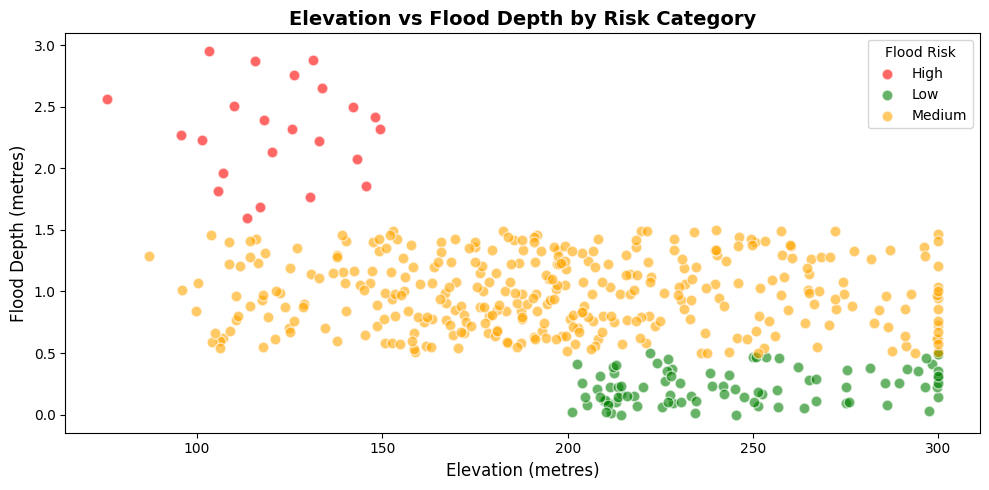

Plot 2 saved


In [4]:
# Plot 2 — Scatter: Elevation vs Flood Depth
fig, ax = plt.subplots(figsize=(10, 5))

colors = {'High': 'red', 'Medium': 'orange', 'Low': 'green'}
for risk, group in df.groupby('flood_risk'):
    ax.scatter(group['elevation_m'], group['flood_depth_m'],
               c=colors[risk], label=risk, alpha=0.6, edgecolors='white', s=60)

ax.set_title('Elevation vs Flood Depth by Risk Category', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Elevation (metres)', fontsize=12)
ax.set_ylabel('Flood Depth (metres)', fontsize=12)
ax.legend(title='Flood Risk')

plt.tight_layout()
plt.savefig('../outputs/v1/plots/02_elevation_vs_depth_scatter.png', dpi=150)
plt.show()
print("Plot 2 saved")

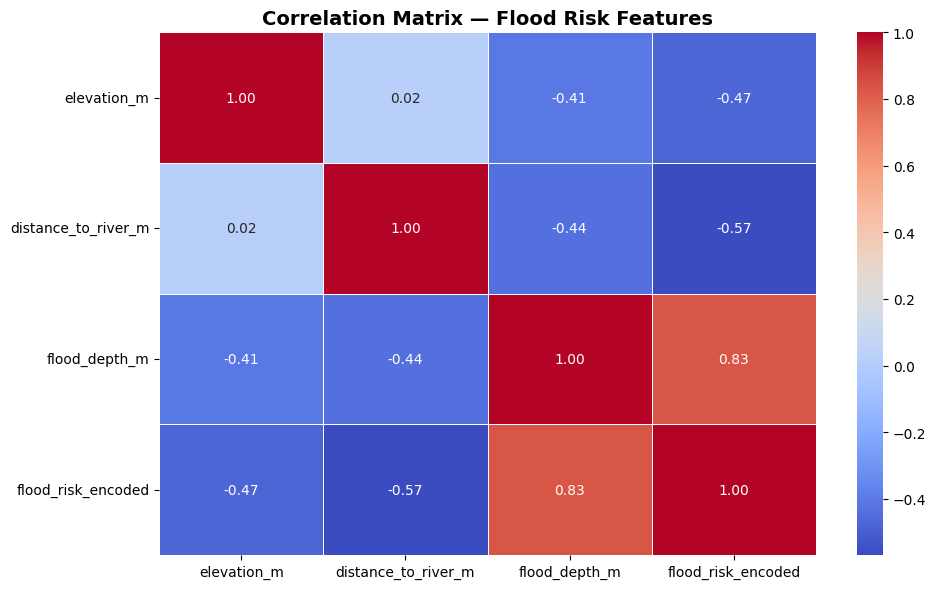

Plot 3 saved


In [5]:
# Plot 3 — Heatmap: Correlation matrix
fig, ax = plt.subplots(figsize=(10, 6))

numeric_cols = ['elevation_m', 'distance_to_river_m', 
                'flood_depth_m', 'flood_risk_encoded']
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Flood Risk Features',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/v1/plots/03_correlation_heatmap.png', dpi=150)
plt.show()
print("Plot 3 saved")

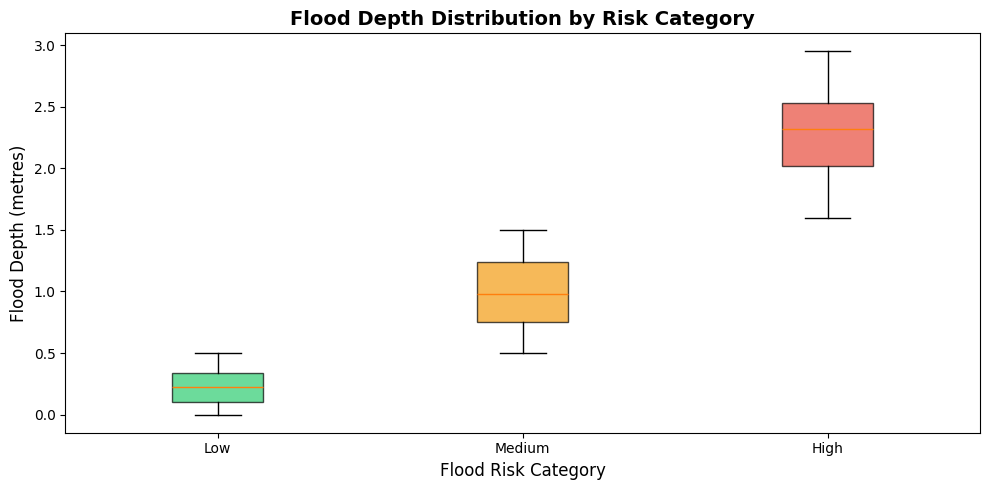

Plot 4 saved


In [6]:
# Plot 4 — Boxplot: Flood depth by risk category
fig, ax = plt.subplots(figsize=(10, 5))

risk_order = ['Low', 'Medium', 'High']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

data_by_risk = [df[df['flood_risk'] == r]['flood_depth_m'].values 
                for r in risk_order]

bp = ax.boxplot(data_by_risk, tick_labels=risk_order, patch_artist=True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Flood Depth Distribution by Risk Category',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Flood Risk Category', fontsize=12)
ax.set_ylabel('Flood Depth (metres)', fontsize=12)

plt.tight_layout()
plt.savefig('../outputs/v1/plots/04_flood_depth_boxplot.png', dpi=150)
plt.show()
print("Plot 4 saved")

In [7]:
print("Plot 4 saved")

Plot 4 saved


In [8]:
import os
files = os.listdir('../outputs/v1/plots')
print(files)

['04_flood_depth_boxplot.png', '02_elevation_vs_depth_scatter.png', '01_elevation_histogram.png', '03_correlation_heatmap.png']
